### Hello buddy, Comments are Welcomed, if you have suggestions & questions ? Please add them in discussion section, happy to have conversion with you, Cheers!

![thanks](https://i.imgflip.com/8ngeel.jpg)

# Import data and package stuff (☞ﾟヮﾟ)☞

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna, warnings, random
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import LabelEncoder

plt.style.use('dark_background')
warnings.simplefilter('ignore', category=FutureWarning)

In [2]:
ds = pd.read_csv('/kaggle/input/heart-failure-prediction-clinical-records/heart_failure_clinical_records.csv')

ds

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,55.0,0,748,0,45,0,263358.03,1.3,137,1,1,88,0
1,65.0,0,56,0,25,0,305000.00,5.0,130,1,0,207,0
2,45.0,0,582,1,38,0,319000.00,0.9,140,0,0,244,0
3,60.0,1,754,1,40,1,328000.00,1.2,126,1,0,90,0
4,95.0,1,582,0,30,0,461000.00,2.0,132,1,0,50,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,45.0,0,582,1,55,0,543000.00,1.0,132,0,0,250,0
4996,60.0,1,582,0,30,1,127000.00,0.9,145,0,0,95,0
4997,95.0,1,112,0,40,1,196000.00,1.0,138,0,0,24,1
4998,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


# Data Insights 🧐

In [3]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       5000 non-null   float64
 1   anaemia                   5000 non-null   int64  
 2   creatinine_phosphokinase  5000 non-null   int64  
 3   diabetes                  5000 non-null   int64  
 4   ejection_fraction         5000 non-null   int64  
 5   high_blood_pressure       5000 non-null   int64  
 6   platelets                 5000 non-null   float64
 7   serum_creatinine          5000 non-null   float64
 8   serum_sodium              5000 non-null   int64  
 9   sex                       5000 non-null   int64  
 10  smoking                   5000 non-null   int64  
 11  time                      5000 non-null   int64  
 12  DEATH_EVENT               5000 non-null   int64  
dtypes: float64(3), int64(10)
memory usage: 507.9 KB


In [4]:
pd.DataFrame(ds.isna().sum()).T.style.background_gradient(cmap='rainbow')

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [5]:
ds.describe(percentiles=[0, .25, .30, .50, .75, .80, 1]).T.style.background_gradient(cmap = 'inferno')

,count,mean,std,min,0%,25%,30%,50%,75%,80%,100%,max
age,5000.000000,60.288736,11.697243,40.000000,40.000000,50.000000,53.000000,60.000000,68.000000,70.000000,95.000000,95.000000
anaemia,5000.000000,0.474400,0.499394,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
creatinine_phosphokinase,5000.000000,586.760600,976.733979,23.000000,23.000000,121.000000,132.000000,248.000000,582.000000,646.000000,7861.000000,7861.000000
diabetes,5000.000000,0.439400,0.496364,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
ejection_fraction,5000.000000,37.734600,11.514855,14.000000,14.000000,30.000000,30.000000,38.000000,45.000000,45.000000,80.000000,80.000000
high_blood_pressure,5000.000000,0.364800,0.481422,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
platelets,5000.000000,265075.404370,97999.758622,25100.000000,25100.000000,215000.000000,223000.000000,263358.030000,310000.000000,327000.000000,850000.000000,850000.000000
serum_creatinine,5000.000000,1.369106,1.009750,0.500000,0.500000,0.900000,1.000000,1.100000,1.400000,1.600000,9.400000,9.400000
serum_sodium,5000.000000,136.808200,4.464236,113.000000,113.000000,134.000000,135.000000,137.000000,140.000000,140.000000,148.000000,148.000000
sex,5000.000000,0.645600,0.478379,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
def mPlotter(r, c, size, _targets, text):
    
    bg = '#010108'
    
    palette = ['#df5337', '#d24644', '#f7d340', '#3339FF', '#440a68', '#84206b', '#f1ef75', '#fbbe23', '#400a67']
    
    font = 'Comic Sans MS'
    
    fig = plt.figure(figsize=size)
    
    fig.patch.set_facecolor(bg)
    
    grid = fig.add_gridspec(r, c)
    
    grid.update(wspace=0.5, hspace=0.25)
    
    __empty_diff = ((r * c) - 1) - len(_targets)
        
    axes = []
    
    for i in range(r):
        for j in range(c):
            axes.append(fig.add_subplot(grid[i, j]))
    
    for idx, ax in enumerate(axes):
        ax.set_facecolor(bg) 
        
        if idx == 0:
            ax.spines["bottom"].set_visible(False)
            ax.tick_params(left=False, bottom=False)
            ax.set_xticklabels([])
            ax.set_yticklabels([])
            ax.text(0.5, 0.5,
                 f'{text}',
                 horizontalalignment='center',
                 verticalalignment='center',
                 fontsize=18, 
                 fontweight='bold',
                 fontfamily=font,
                 color="#fff")
        else:
            if (idx - 1) < len(_targets):
                ax.set_title(_targets[idx - 1].capitalize(), fontsize=14, fontweight='bold', fontfamily=font, color="#fff")
                ax.grid(color='#fff', linestyle=':', axis='y', zorder=0,  dashes=(1,5))
                ax.set_xlabel("")
                ax.set_ylabel("")
            else:
                ax.spines["bottom"].set_visible(False)
                ax.tick_params(left=False, bottom=False)
                ax.set_xticklabels([])
                ax.set_yticklabels([])
                
        ax.spines["left"].set_visible(False)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        
    def cb(ax):
        ax.set_xlabel("")
        ax.set_ylabel("")
        
    if __empty_diff > 0:
        axes = axes[:-1*__empty_diff]
        
    return axes, palette, cb

In [7]:
target = 'DEATH_EVENT'

dis_cols = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']
cont_cols = list(set(ds.columns) - set([*dis_cols, target]))

len(cont_cols), len(dis_cols)

(7, 5)

# Data Visualization 📊

![eda](https://i.imgflip.com/8o7sml.jpg)

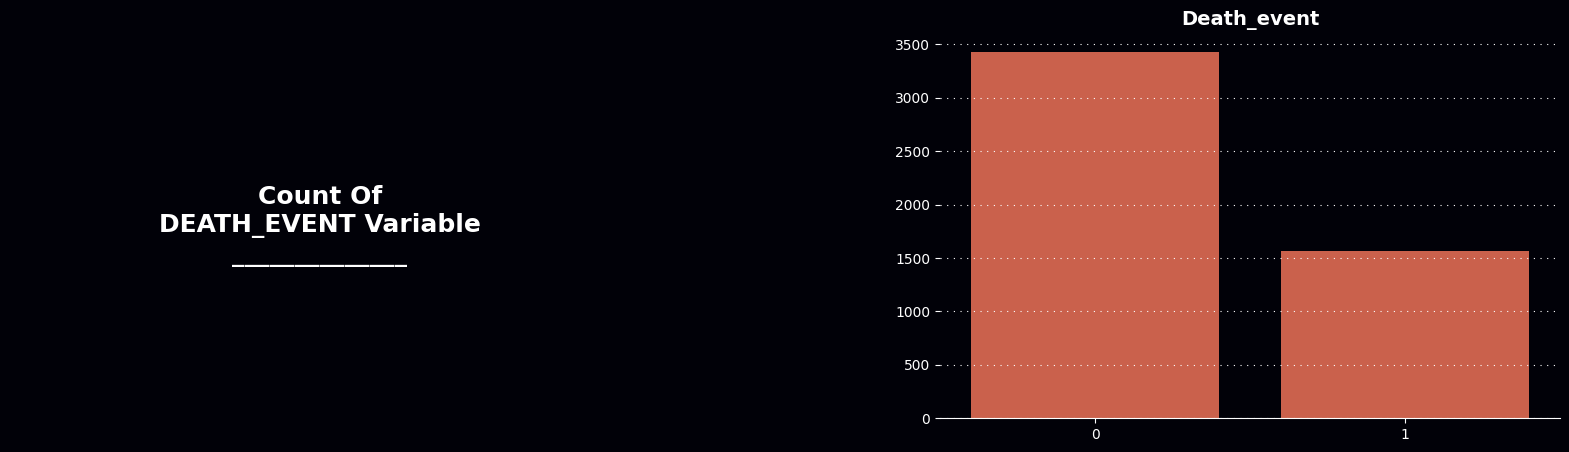

In [8]:
axes, palette, cb = mPlotter(1, 2, (20, 5), [target], 'Count Of\nDEATH_EVENT Variable\n______________')

sns.countplot(x=ds[target], ax = axes[1], color=palette[0])
cb(axes[1])

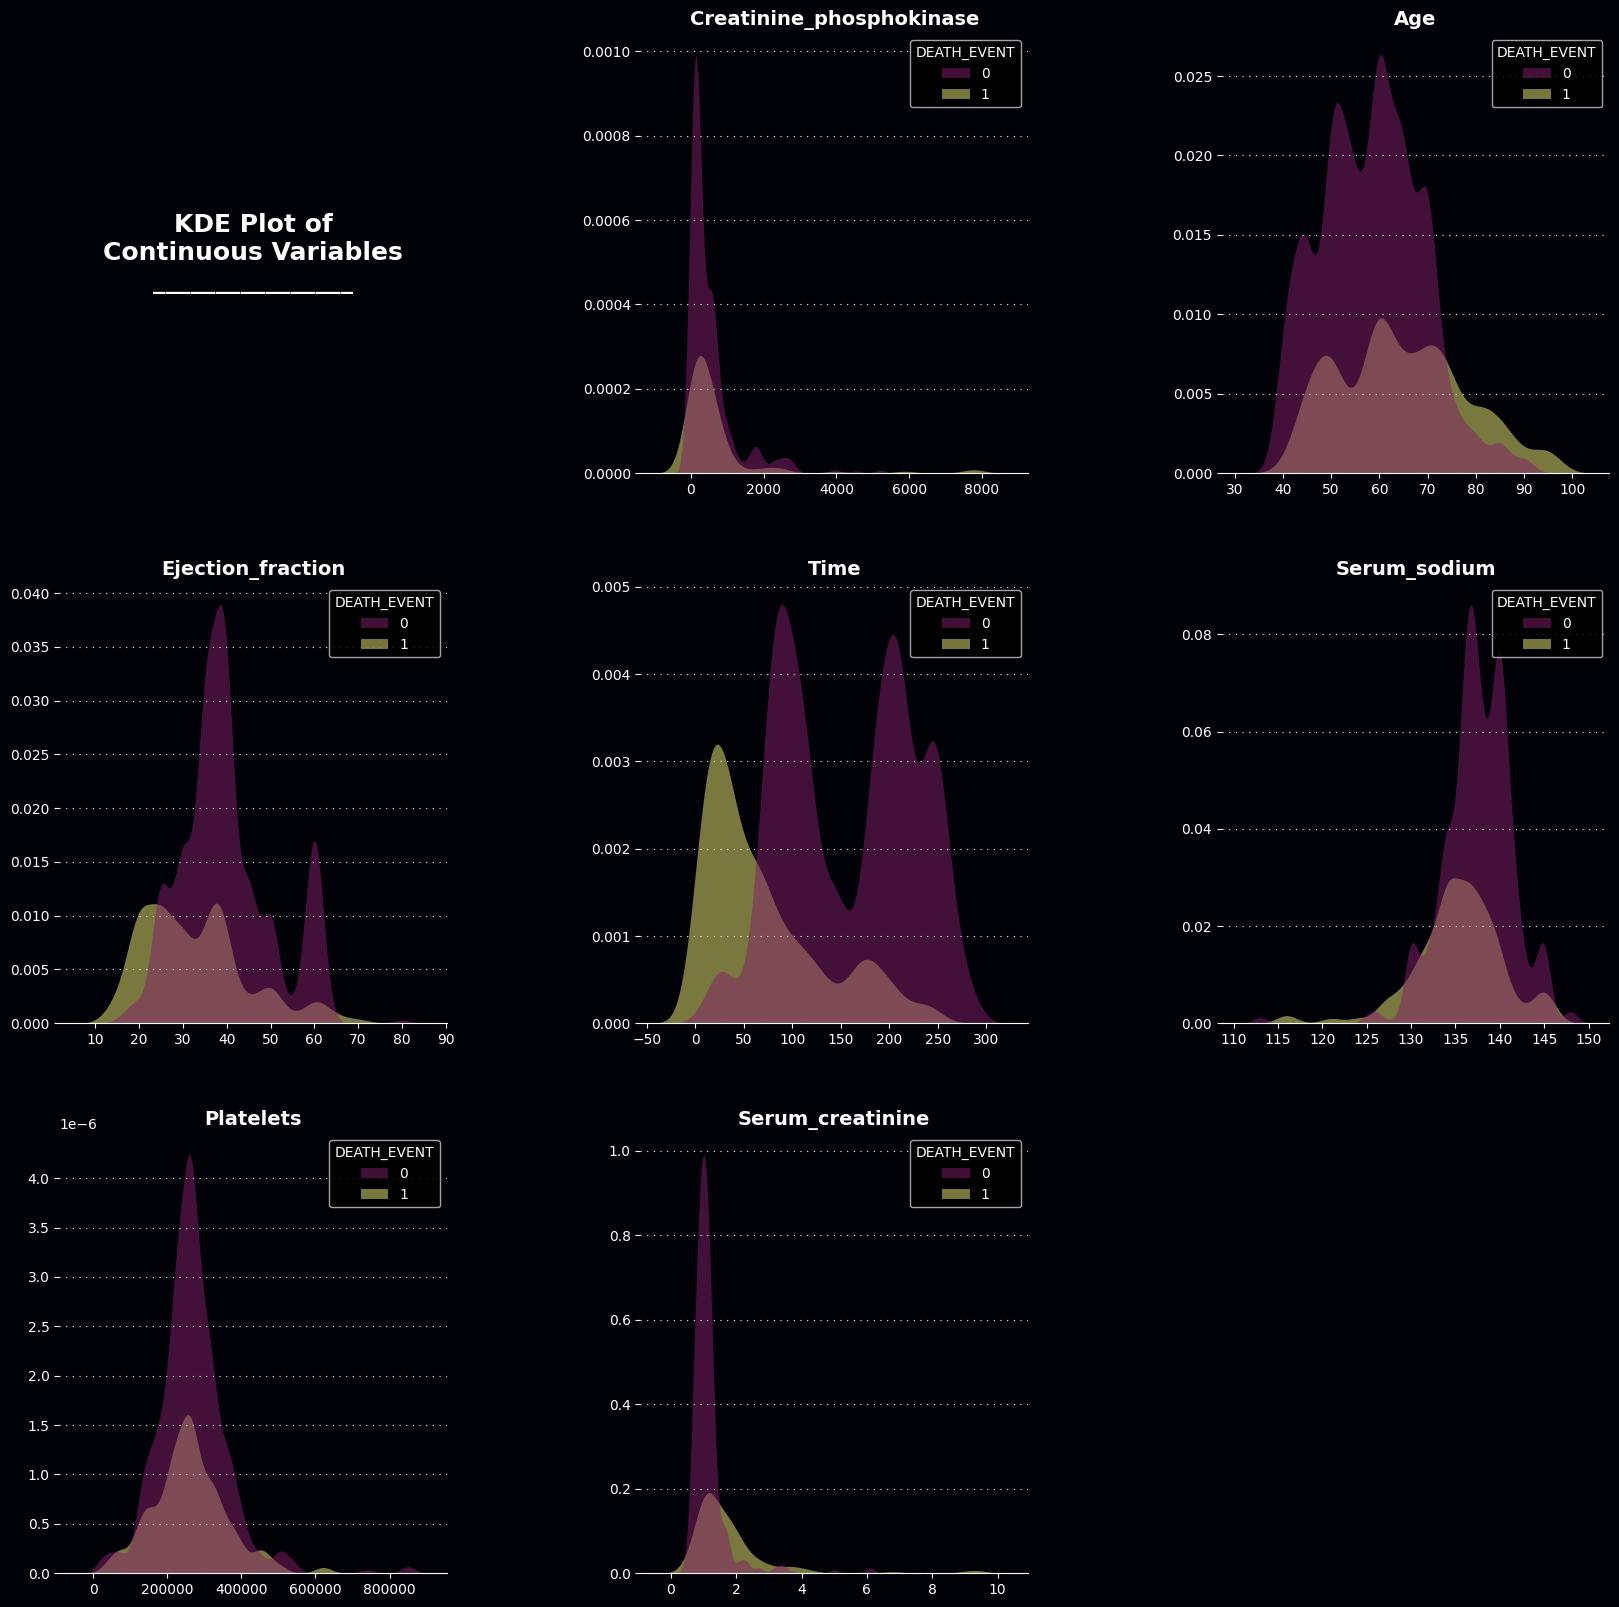

In [9]:
axes, palette, cb = mPlotter(3, 3, (20, 20), cont_cols, 'KDE Plot of\nContinuous Variables\n________________')

for col, ax in zip(cont_cols, axes[1:]):
    sns.kdeplot(data=ds, x=col, ax=ax, hue=target, palette=palette[5:7], alpha=.5, linewidth=0, fill=True)
    cb(ax)

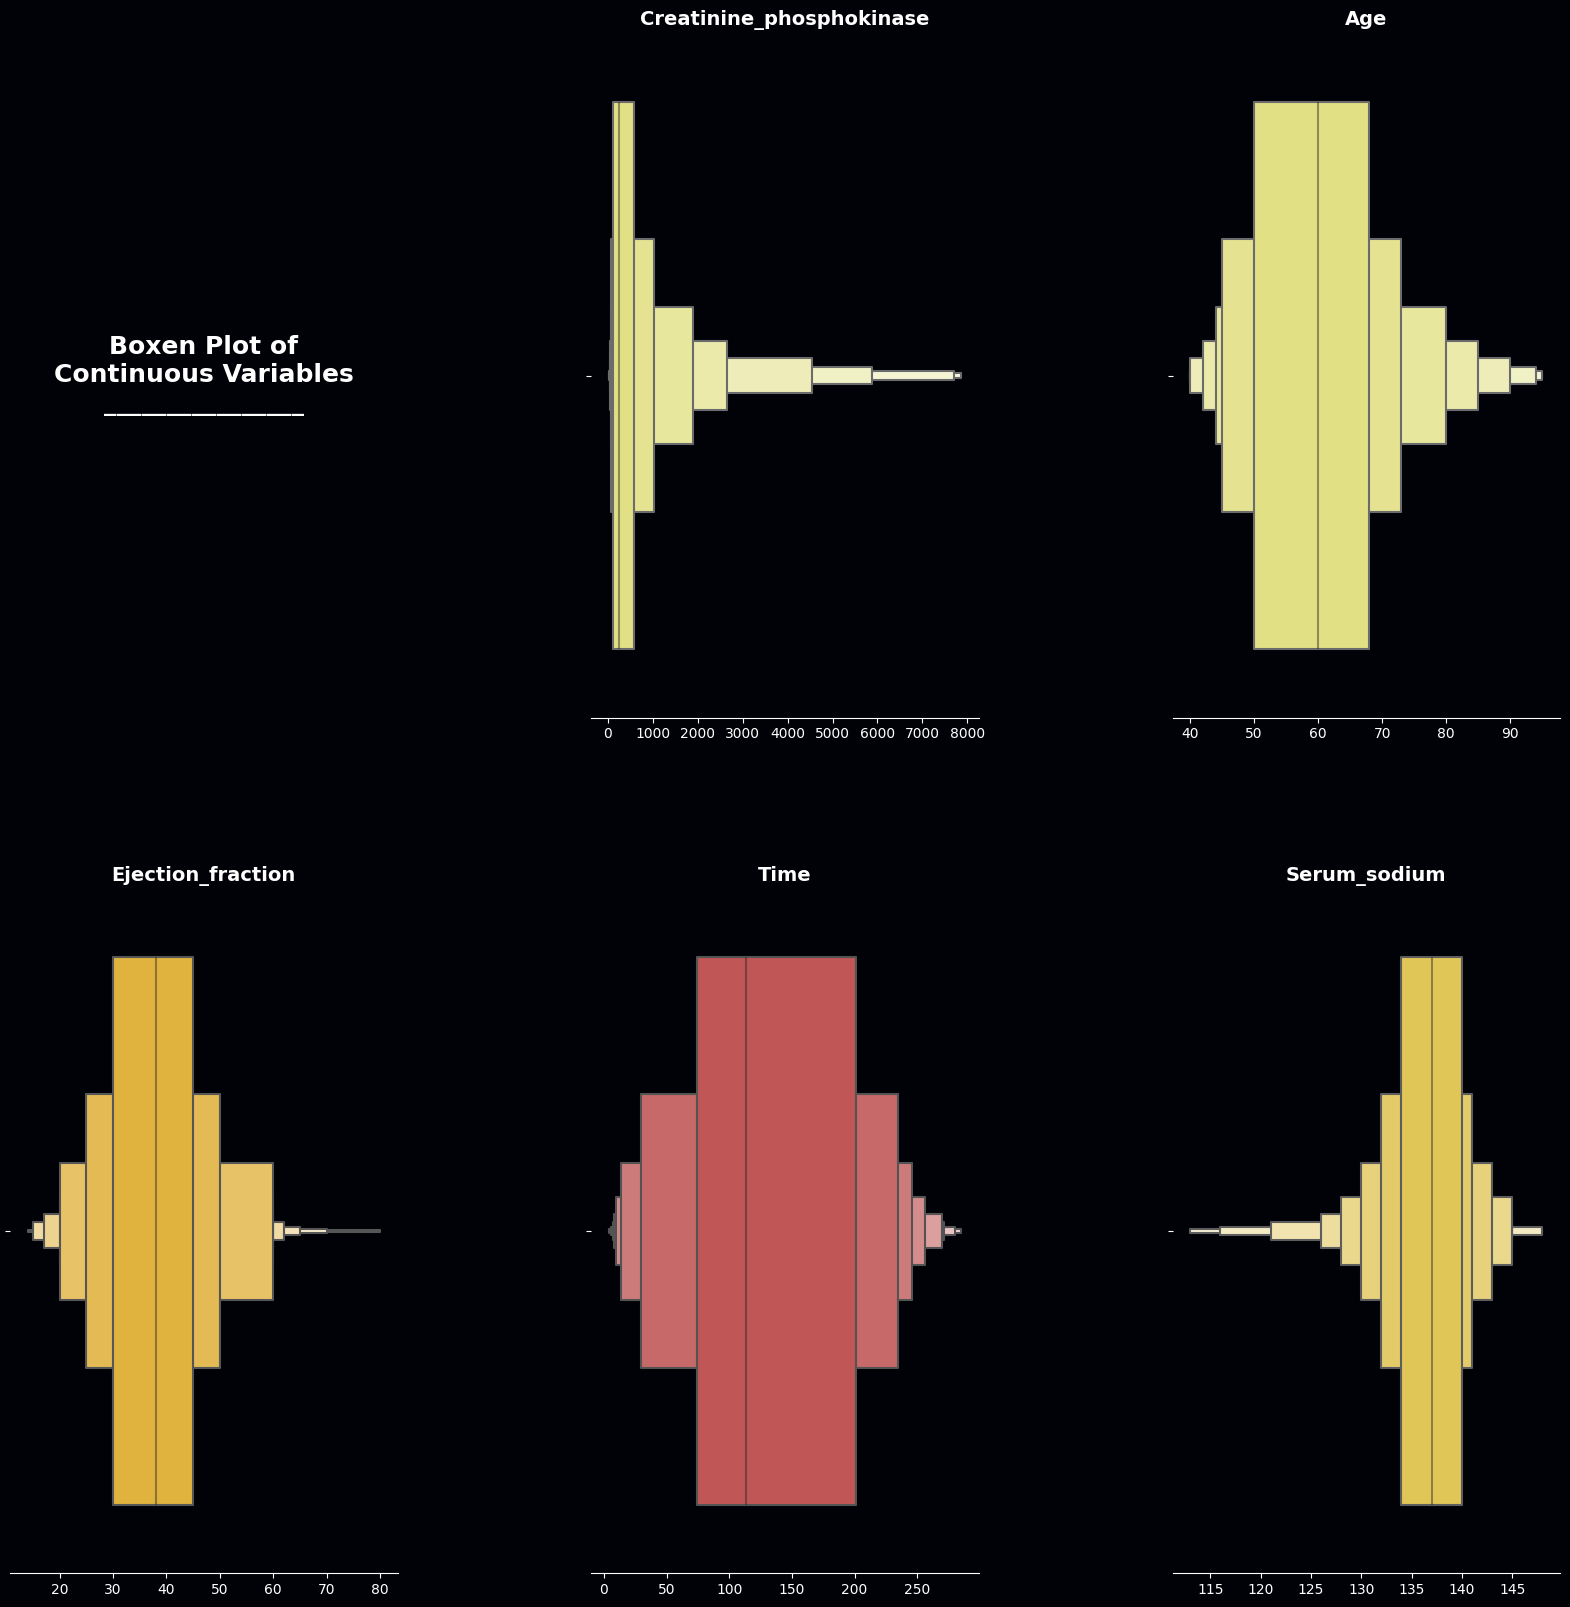

In [10]:
axes, palette, cb = mPlotter(2, 3, (20, 20), cont_cols, 'Boxen Plot of\nContinuous Variables\n________________')

for col, ax in zip(cont_cols, axes[1:]):
    sns.boxenplot(data=ds, x=col, ax=ax, palette=[palette[random.randint(0, len(palette)-1)]])
    cb(ax)

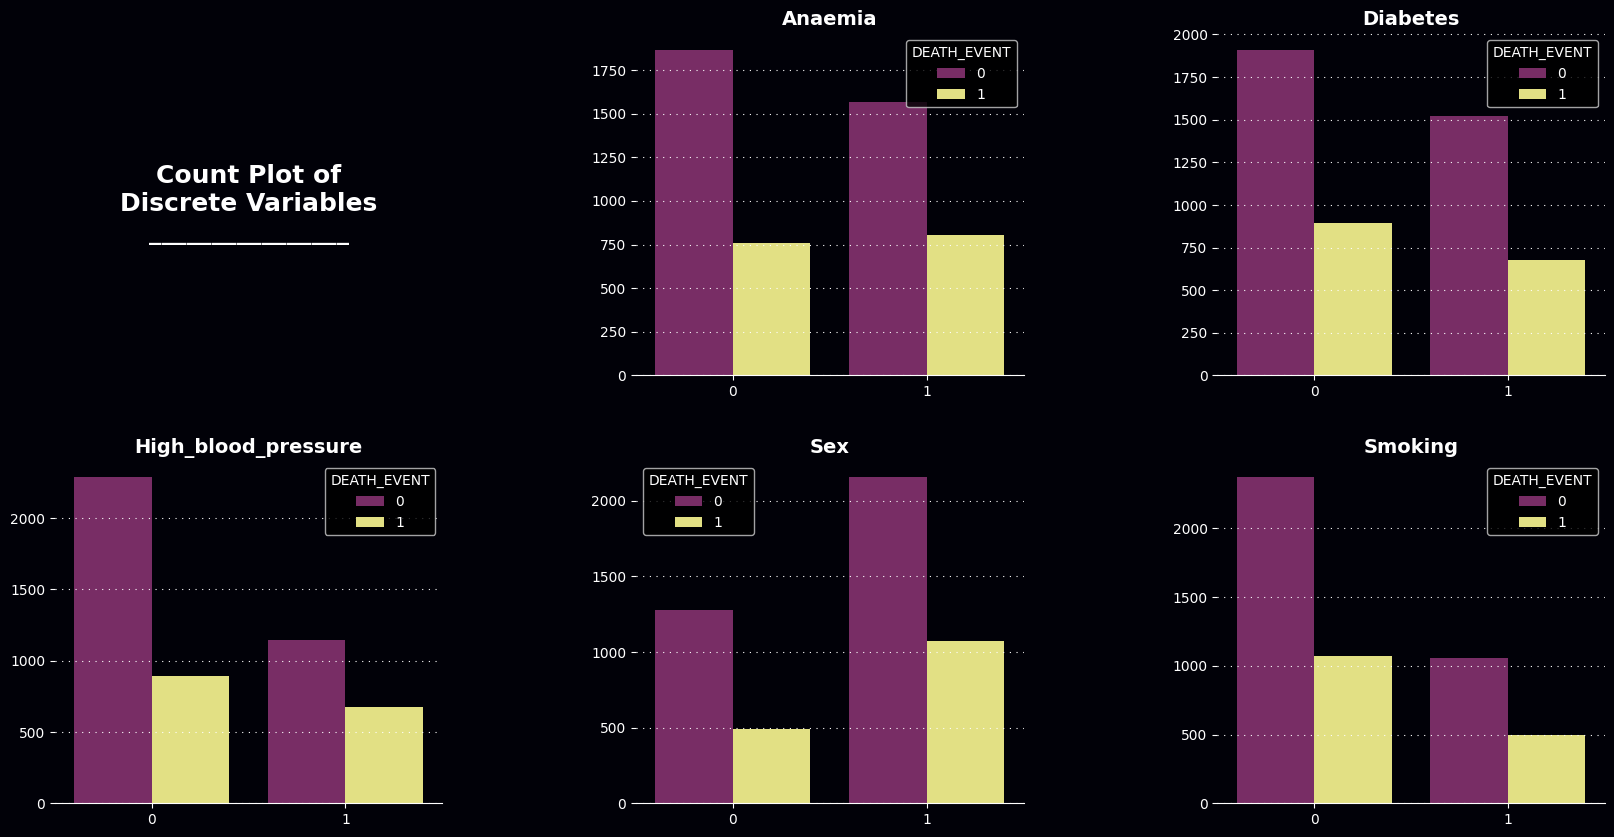

In [11]:
axes, palette, cb = mPlotter(2, 3, (20, 10), dis_cols, 'Count Plot of\nDiscrete Variables\n________________')

for col, ax in zip(dis_cols, axes[1:]):
    sns.countplot(data=ds, x=col, ax=ax, hue=target, palette=palette[5:7])
    cb(ax)

In [12]:
ax = px.scatter_3d(ds, x="age", y="platelets", z="time", template= "plotly_dark", color="DEATH_EVENT")

ax.show()

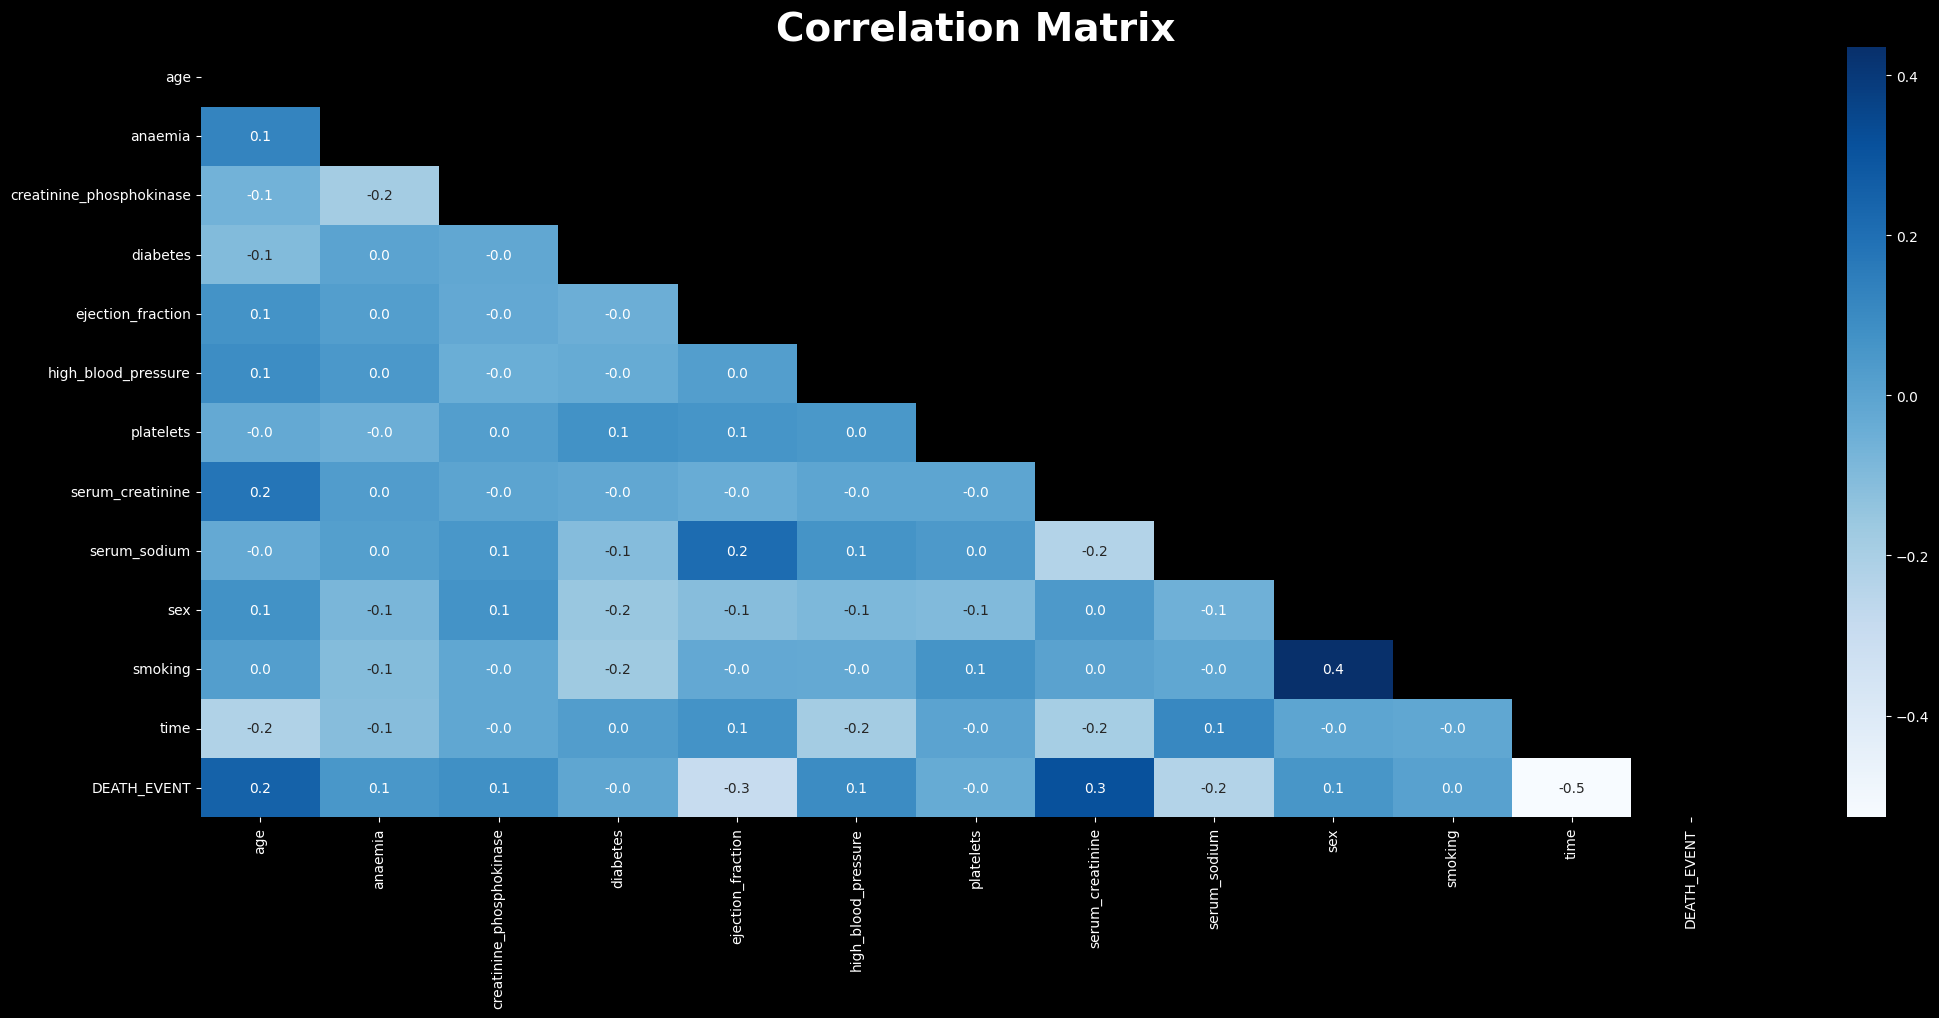

In [13]:
fig = plt.figure(figsize=(25, 10))

gs = fig.add_gridspec(1, 1)

gs.update(wspace=0.3, hspace=0.15)

ax = fig.add_subplot(gs[0, 0])

ax.set_title("Correlation Matrix", fontsize=28, fontweight='bold', fontfamily='Comic Sans MS', color="#fff")

sns.heatmap(ds.corr().transpose(), mask=np.triu(np.ones_like(ds.corr().transpose())), fmt=".1f", annot=True, cmap='Blues')

plt.show()

# Split the cakes equal 🍰

In [14]:
x_train, x_test, y_train, y_test = train_test_split(ds.iloc[:,:-1], ds.iloc[:, -1], random_state=3, train_size=.7)

x_train.shape, y_train.shape, x_test.shape, y_test.shape

((3500, 12), (3500,), (1500, 12), (1500,))

# The Black Magic 🧿

![model](https://i.imgflip.com/8o7ssy.jpg)

In [15]:
voting_classifier = VotingClassifier(
    estimators=[('cat', CatBoostClassifier(verbose=0)), ('xg', XGBClassifier()), ('lgbm', LGBMClassifier(verbose=-1))],
    voting='soft',
    verbose=False
)

voting_classifier.fit(x_train, y_train)

VotingClassifier(estimators=[('cat',
                              <catboost.core.CatBoostClassifier object at 0x7b864ac7f280>),
                             ('xg',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None, gamma=None,
                                            grow_policy=No...
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None,
                                            num_parallel_tree=None,
                                            random_state=None, ...)),
                             ('lgbm', LGBMClassifier(verbose=-1))],
                 voting='soft')

In [16]:
y_pred = voting_classifier.predict(x_test)

# Oversee the model performance 👀

In [17]:
print (classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1028
           1       0.98      1.00      0.99       472

    accuracy                           0.99      1500
   macro avg       0.99      0.99      0.99      1500
weighted avg       0.99      0.99      0.99      1500



![thanksagain](https://i.imgflip.com/8ou6ip.jpg)

<Axes: >

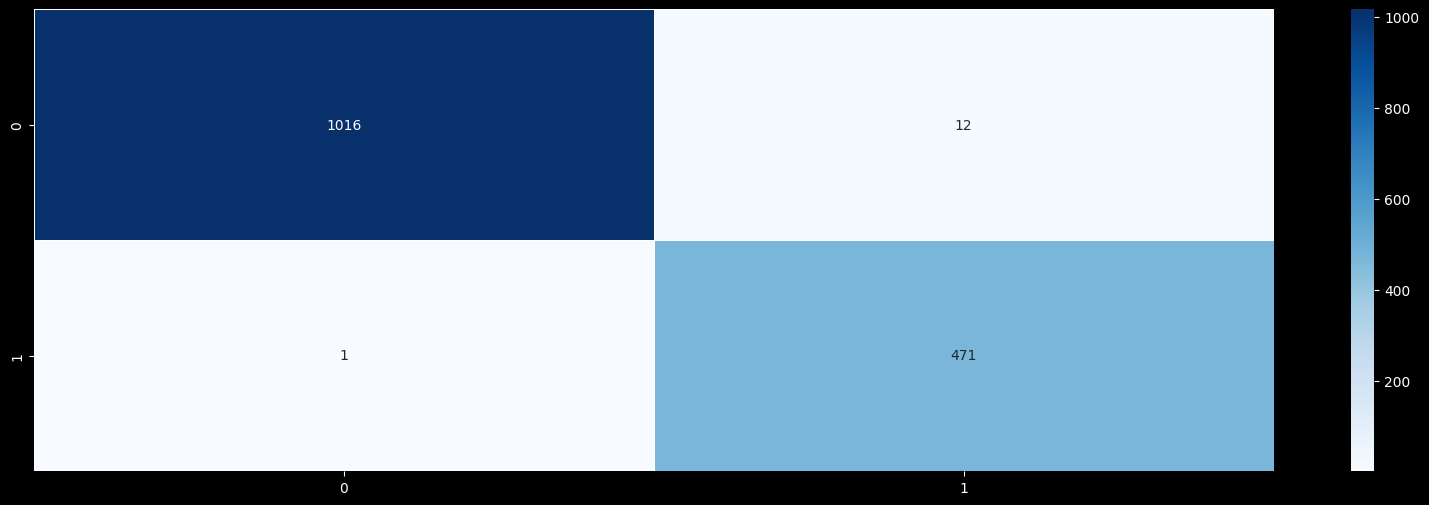

In [18]:
plt.subplots(figsize=(20, 6))

sns.heatmap(confusion_matrix(y_pred, y_test), annot = True, fmt="d", cmap="Blues", linewidths=.5)

![thanksagain](https://i.imgflip.com/8o7tp4.jpg)

#  Any suggestion to improve performance are welcomed, Peace bro ✌